오토인코더 개념 복습

인코더 / 디코더 구조 구현

GELU 등 핵심 요소 설명

모델 선언 및 전처리 코드 포함

여러 시각 자료를 통한 구조 설명

In [ ]:
import torch.nn as nn

# 이미지와 같은 고차원 데이터를 받아서, 중요한 정보만 담은 저차원 벡터(latent vector)로 압축하는 인코더 모델
class Encoder(nn.Module):
    def __init__(self, num_input_channels, base_channel_size, latent_dim):  # base_channel_size: 특징 맵 크기, latent_dim: 마지막의 나올 벡터의 크기
        super().__init__()

        self.net = nn.Sequential(
        nn.Conv2d(num_input_channels, base_channel_size, kernel_size=3, padding=1, stride=2),  # 32x32 => 16x16
        nn.GELU(),
        nn.Conv2d(base_channel_size, base_channel_size, kernel_size=3, padding=1),
        nn.GELU(),
        nn.Conv2d(base_channel_size, 2 * base_channel_size, kernel_size=3, padding=1, stride=2),  # 16x16 => 8x8
        nn.GELU(),
        nn.Conv2d(2 * base_channel_size, 2 * base_channel_size, kernel_size=3, padding=1),
        nn.GELU(),

        nn.Conv2d(2 * base_channel_size, 2 * base_channel_size, kernel_size=3, padding=1, stride=2),  # 8x8 => 4x4
        nn.GELU(),
        nn.Flatten(),
        nn.Linear(2 * base_channel_size * 16, latent_dim),   # base_channel이 32라 하면 결국에는 2배인 64가 되고, 16=4*4(피처맵)의 값임.
    )

    def forward(self, x):
       return self.net(x)


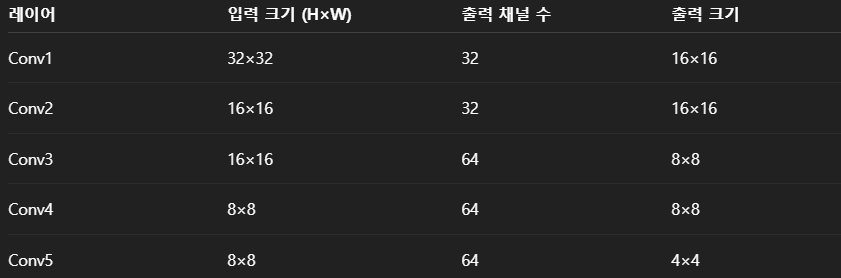

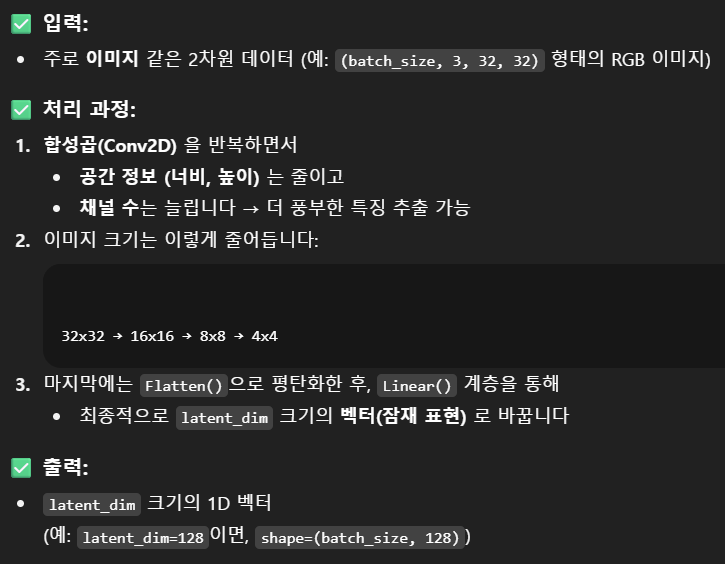

**GELU를 사용하는 이유**
- 부드러움(Smoothness): 0 부근에서 미분이 연속이라 기울기 소실/폭주 완화에 유리하고, 학습이 안정적입니다. (ReLU는 0에서 미분이 뚝 끊깁니다.)
- 정보 보존: 작은 음수도 조금은 통과시켜서, ReLU처럼 음수 영역 뉴런이 “죽어버리는(dead)” 현상을 줄입니다.
- 경험적 성능: NLP의 Transformer(BERT, GPT 계열), 비전의 최신 아키텍처에서 GELU가 ReLU보다 성능이 더 좋은 경우가 자주 보고되었습니다. CNN에도 무난히 잘 맞습니다.

In [ ]:
# Encoder의 반대 역할
# latent vector를 입력받아 원래 이미지의 크기(예: 32*32*채널)로 복원하는 구조
# output_padding: ConvTranspose2d에서만 사용하며,
# 업샘플링 후 출력의 크기가 약간 부족할 때, 1~2픽셀 정도를 '덧붙여서' 정확한 크기로 맞추기 위해 用 (패딩 추가X, 출력사이즈를 정밀하게 맞추기 위해 用)
# 주로 stride > 1일 때 用

class Decoder(nn.Module):
    def __init__(self, num_input_channels, base_channel_size, latent_dim):
        super().__init__()

        self.linear = nn.Sequential(nn.Linear(latent_dim, 2 * 16 * base_channel_size), nn.GELU())
        self.net = nn.Sequential(
            # 다운샘플링의 반대, 업샘플링을 해줌
            nn.ConvTranspose2d(
                2 * base_channel_size, 2 * base_channel_size, kernel_size=3, output_padding=1, padding=1, stride=2
            ),  # 4x4 => 8x8 (업샘플링)
            nn.GELU(),
            nn.Conv2d(2 * base_channel_size, 2 * base_channel_size, kernel_size=3, padding=1),
            nn.GELU(),
            nn.ConvTranspose2d(2 * base_channel_size, base_channel_size, kernel_size=3, output_padding=1, padding=1, stride=2),  # 8x8 => 16x16
            nn.GELU(),
            nn.Conv2d(base_channel_size, base_channel_size, kernel_size=3, padding=1),   # 유지
            nn.GELU(),
            nn.ConvTranspose2d(
                base_channel_size, num_input_channels, kernel_size=3, output_padding=1, padding=1, stride=2
            ),  # 16x16 => 32x32
            nn.Tanh(),  # 범위가 -1 ~ 1이므로 더 다양하게 뽑을 수 있다. (이미지 표현 시 자주 사용)
        )

    def forward(self, x):
        x = self.linear(x)
        x = x.reshape(x.shape[0], -1, 4, 4)
        x = self.net(x)
        return x

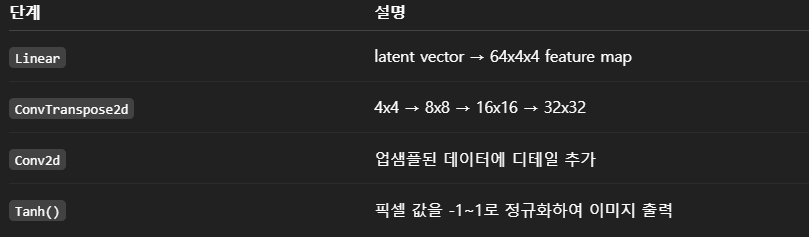

In [ ]:
class Autoencoder(nn.Module):
    def __init__(self, num_input_channels, base_channel_size, latent_dim):
        super().__init__()

        self.encoder = Encoder(num_input_channels, base_channel_size, latent_dim)
        self.decoder = Decoder(num_input_channels, base_channel_size, latent_dim)

    def forward(self, x):
        latent = self.encoder(x)
        output = self.decoder(latent)
        return latent, output

In [ ]:
model = Autoencoder(num_input_channels=3, base_channel_size=64, latent_dim=256)
model

Autoencoder(
  (encoder): Encoder(
    (net): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): GELU(approximate='none')
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): GELU(approximate='none')
      (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (5): GELU(approximate='none')
      (6): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (7): GELU(approximate='none')
      (8): Conv2d(128, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (9): GELU(approximate='none')
      (10): Flatten(start_dim=1, end_dim=-1)
      (11): Linear(in_features=2048, out_features=256, bias=True)
    )
  )
  (decoder): Decoder(
    (linear): Sequential(
      (0): Linear(in_features=256, out_features=2048, bias=True)
      (1): GELU(approximate='none')
    )
    (net): Sequential(
      (0): ConvTranspose2d(128, 128, kernel_size=(3, 3), stride=(2, 2), pa

In [ ]:
# 전처리

import torch
from torchvision.transforms import v2

trn_transforms = v2.Compose([
    v2.ToImage(),  # PIL > Tensor 이미지 변환
    v2.RandomResizedCrop(size=(32, 32), antialias=True),  # 랜덤한 위치&비율로 자르고 32x32로 리사이즈
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomVerticalFlip(p=0.5),
    v2.ToDtype(torch.float32, scale=True),  # float32로 변환, 0~1 정규화
    v2.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # [0, 1] > [-1, 1] 로 변환
])  # 훈련데이터를 다양하게 만들어서 모델이 일반화(과적합 방지)되도록 도와준다.

test_transforms = v2.Compose([
    v2.ToImage(),
    v2.Resize(size=(32, 32), antialias=True),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])  # 테스트시에는 성능을 정확하게 평가해야 하므로 데이터 증강은 하지 않고 정규화만 진행.

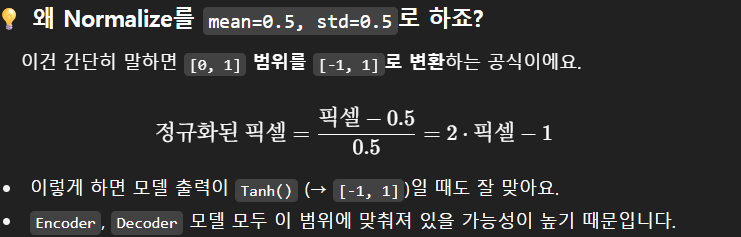

In [ ]:
# CIFAR-10 이미지 데이터셋을 불러오고, 각각 훈련용과 테스트용으로 적절한 전처리(transform) 적용

from torchvision.datasets import CIFAR10
trn_dataset = CIFAR10(".", train=True, download=True, transform=trn_transforms)
test_dataset = CIFAR10(".", train=False, download=True, transform=test_transforms)

100%|██████████| 170M/170M [00:03<00:00, 48.9MB/s]


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torchvision.utils as vutils

def imshow(inputs, title):

    # 정규화 해제: [-1, 1] > [0, 1]
    mean=0.5
    std=0.5
    inputs=std*inputs+mean

    # 픽셀 범위 제한: 정규화 해제 후에도 혹시 모를 범위 밖 값을 [0, 1]로 자름
    inputs=torch.clip(inputs, 0, 1)

    # 이미지 그리드 만들기
    grid = vutils.make_grid(inputs, padding=2, normalize=True)

    # 시각화
    plt.figure(figsize=(8,8))
    plt.axis("off")
    plt.title(title)
    plt.imshow(np.transpose(grid, (1,2,0)))
    plt.show()
    plt.close()


# 모델학습에서는 정규화가 필수지만, 시각화할 때는 정규화 해제가 꼭 필요하다.
# 정규화는 모델이 더 빠르고 안정적으로 학습되도록 도와준다.
# 정규화의 장점: 값의 범위가 좁고 일정하여 > 기울기 폭발/소실 방지
# 평균이 0에 가까워 > 학습이 더 빠르고 안정적으로 진행됨
# 채널마다 값 분포를 맞춰 > R, G, B의 비중 균형
# 정규화된 이미지는 사람이 보기엔 이상한 이미지이기 때문에 시각화할 때에는 해제한다.

In [ ]:
# PyTorch에서 데이터셋을 모델 학습에 적합한 형태로 불러오는 과정

import torch

trn_loader = torch.utils.data.DataLoader(trn_dataset, batch_size=64, shuffle=True, num_workers=2)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)

In [ ]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [ ]:
# 오토인코더 모델 학습

from tqdm import tqdm

def train(model, criterion, optimizer, trn_loader, test_loader, device, num_epochs):
    for epoch in range(num_epochs):

        print(f"\n Epoch [{epoch+1}/{num_epochs}]")
        model.train()
        trn_loss = 0.0
        for inputs, _ in tqdm(trn_loader):  # _ : 레이블은 사용하지 않음 (오토인코더니까 입력 자체가 정답)
            inputs = inputs.to(device)  # GPU로 전송

            _, outputs = model(inputs)
            loss = criterion(outputs, inputs)  # 복원된 이미지와 원본의 차이를 계산 (예: MSE)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            trn_loss += loss.item() * inputs.size(0)

        trn_epoch_loss = trn_loss / len(trn_loader.dataset)
        print(f"[Train] Loss: {trn_epoch_loss:.4f}")

        # 검증 루프 (학습x, 성능만 측정)
        with torch.no_grad():
            model.eval()
            test_loss = 0.0
            for inputs, _ in tqdm(test_loader):
                inputs = inputs.to(device)

                _, outputs = model(inputs)
                loss = criterion(outputs, inputs)

                test_loss += loss.item() * inputs.size(0)

            test_epoch_loss =  test_loss / len(test_loader.dataset)
            print(f"[Test] Loss: {test_epoch_loss:.4f}")
            imshow(inputs.cpu(), "Inputs")
            imshow(outputs.cpu(), "outputs")


# 학습 루프: train()으로 입력 > 복원 > loss > backward() > step()
# 평가 루프: eval() + no_grad() > 입력 > 복원 > loss 측정만

In [ ]:
# 오토인코더 모델을 학습하기 위한 기본 설정

import torch.optim as optim

model = model.to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
train(model, criterion, optimizer, trn_loader, test_loader, device, num_epochs=10)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# 인코더 부분을 이용해서 잠재 벡터 추출
# data_loader로부터 이미지를 받아서 해당 이미지들을 인코더에 통과시켜 얻은 잠재 벡터와 함께 반환

def get_embed(model, data_loader):
    image_list, embed_list = [], []  # 원본 이미지 저장, 잠재 벡터 저장
    model.eval()

    with torch.no_grad():
        for inputs, _ in tqdm(data_loader):  # 이미지만 꺼내고 라벨은 무시
            inputs = inputs.to(device)
            latents = model.encoder(inputs)

            image_list.append(inputs.cpu())  # CPU로 이동해 리스트에 저장
            embed_list.append(latents)  # 나중에 한꺼번에 torch.cat()으로 연결

    image_list = torch.cat(image_list, dim=0)
    embed_list = torch.cat(embed_list, dim=0)
    return image_list, embed_list  # 배치 단위로 추출한 이미지/벡터들을 모두 이어 붙여서 반환

모델을 평가 모드로 실행하면서, 인코더를 통해 이미지에서 "잠재 벡터(latent vector)"를 뽑아내는 핵심 코드

```
    with torch.no_grad():
        for inputs, _ in tqdm(data_loader):
            inputs = inputs.to(device)
            latents = model.encoder(inputs)
```
1. **with torch.no_grad()** : 그래디언트는 계산하지 않겠다.
- 추론/평가 중일 때 用 (학습X)
- 메모리 절약 + 속도 향상
- 여기서는 임베딩만 추출하는 작업이기 때문에 학습이 필요 없다!

2. **for inputs, _ in tqdm(data_loader)** : data_loader에서 데이터를 하나씩 꺼내 반복
- inputs: 이미지 배치(예: [64, 3, 32, 32])
- _: 레이블 (오토인코더에서는 사용하지 않기 때문에 버림)


3. inputs = inputs.to(device) : 연산을 GPU 또는 CPU로 이동

4. **latents = model.encoder(inputs)**: 인코더로 잠재 벡터 추출


In [ ]:
# query image("이 이미지랑 비슷한 걸 찾아줘!" 하고 던져주는 기준 이미지)와 가장 비슷하거나 다른 이미지들을 찾는 함수
# 오토인코더가 학습한 잠재 공간이 얼마나 잘 "유사도"를 반영하는지 확인

# query_embed: 쿼리 이미지의 임베딩 벡터
# key_embeds: 비교 대상 이미지들의 임베딩 벡터
# cdist: 임베딩 간 유클리드 거리 계산
# topk: 가장 유사한 k개 이미지
# bottomk: 가장 덜 유사한 k개 이미지

def find_similar_images(query_image, query_embed, key_images, key_embeds, k=7):
    dist = torch.cdist(query_embed[None :], key_embeds, p=2)
    dist = dist.squeeze(dim=0)

    # largest=False: 가장 작은 거리 = 가장 유사한 Top-k의 인덱스를 얻음
    _, topk_indices = torch.topk(dist, k, largest=False)
    # 쿼리이미지를 맨 앞에 붙이고, Top-k 이미지들을 이어붙여 그리드로 보여줌
    topk_images = torch.cat([query_image[None], key_images[topk_indices.cpu()]], dim=0)
    imshow(topk_images, f"Top-{k} images")

    _, bottomk_indices = torch.topk(dist, k, largest=True)
    bomttomk_images = torch.cat([query_image[None], key_images[bottomk_indices.cpu()]], dim=0)
    imshow(bomttomk_images, f"Bottom-{k} images")

In [ ]:
test_images, test_embeds = get_embed(model, test_loader)

# 1. get_embed(model, test_loader) 호출
# model: 학습이 끝난 오토인코더 모델 (encoder + decoder 포함)
# test_loader: 테스트용 데이터셋을 담은 DataLoader
# get_embed() 함수 내부에서는:
# 1. model.encoder(inputs) 로 잠재 벡터를 추출
# 2. 입력 이미지(inputs)와 잠재 벡터(latents)를 리스트에 모아서
# 3. 최종적으로 torch.cat()으로 하나의 큰 텐서로 합쳐 반환


# 2. 반환값 저장
# test_images → 테스트셋 이미지들 (torch tensor)
# shape 예: [10000, 3, 32, 32]
# test_embeds → 이미지들의 잠재 벡터 (latent vector)
# shape 예: [10000, latent_dim]
# (예: latent_dim=128 → [10000, 128])

100%|██████████| 157/157 [00:09<00:00, 15.76it/s]


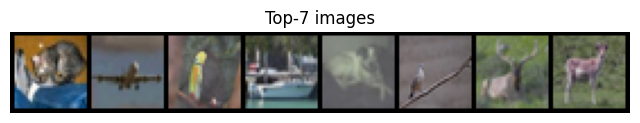

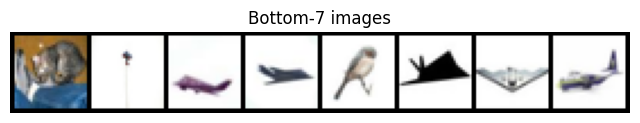

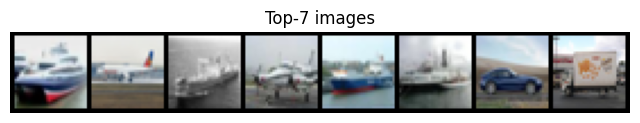

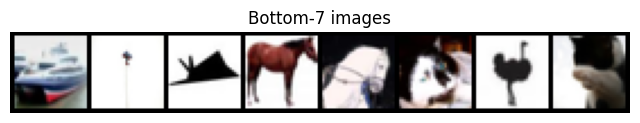

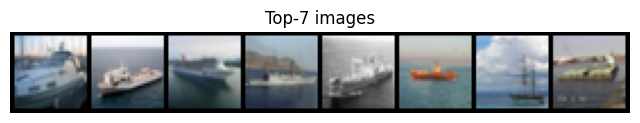

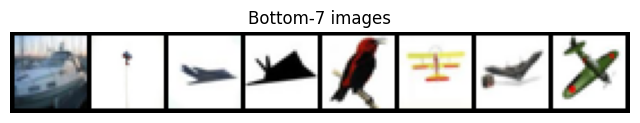

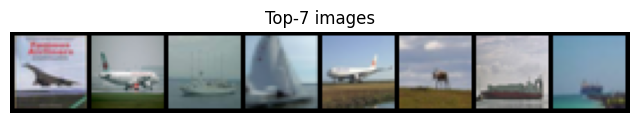

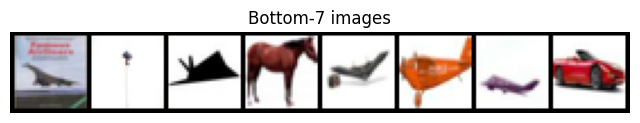

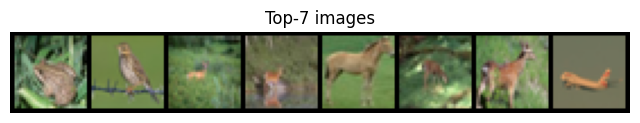

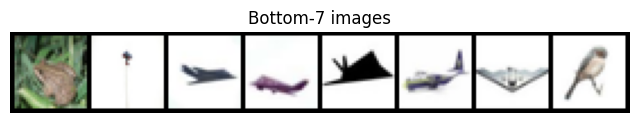

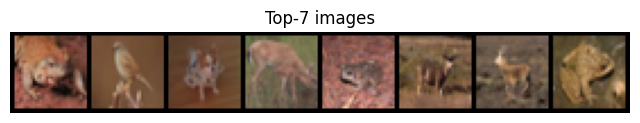

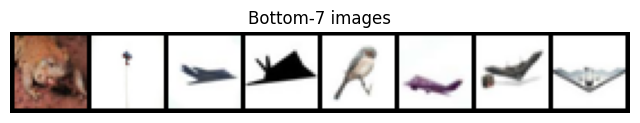

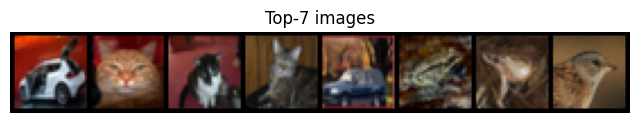

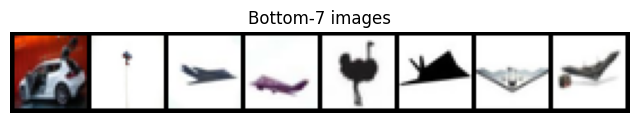

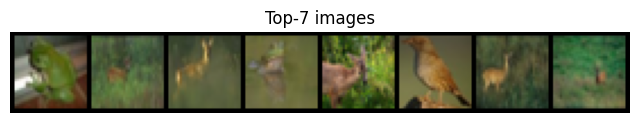

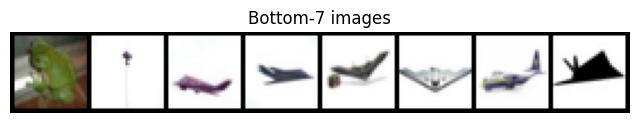

In [19]:
# for i in range(8):
#     find_similar_images(test_images[i], test_embeds[i], test_images[i+1:], test_embeds[i+1:])

for i in range(8):
    anchor_embed = test_embeds[i].unsqueeze(0)  # [256] → [1, 256]
    find_similar_images(test_images[i], anchor_embed, test_images[i+1:], test_embeds[i+1:])


# i = 0부터 7까지 반복하면서:
# 기준 이미지 test_images[i]와 해당 임베딩을 설정
# 그 다음 이미지들 (i+1부터 끝까지)와 유사도 비교
# 가장 유사한 이미지들을 시각화하거나 리턴하는 식으로 작동

In [20]:
# 입력 이미지에 가우시안 노이즈 추가

def add_noise(inputs):
    noise = torch.randn(inputs.size()) * 0.2
    noisy_inputs = inputs + noise
    return noisy_inputs

In [21]:
def train_with_noise(model, criterion, optimizer, trn_loader, test_loader, device, num_epochs):
  for epoch in range(num_epochs):

    print(f"\n Epoch [{epoch+1}/{num_epochs}]")

    model.train()
    trn_loss = 0.0
    for inputs, _ in tqdm(trn_loader):
      inputs_with_noise = add_noise(inputs)
      inputs_with_noise = inputs_with_noise.to(device)
      inputs = inputs.to(device)

      _, outputs = model(inputs_with_noise)  # 예측된 아웃풋
      loss = criterion(outputs, inputs)  # 예측된 아웃풋과 원본과 비교

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      trn_loss += loss.item() * inputs.size(0)

    trn_epoch_loss = trn_loss / len(trn_loader.dataset)
    print(f"[Train] Loss: {trn_epoch_loss:.4f}")

    with torch.no_grad():
      model.eval()
      test_loss = 0.0
      for inputs, _ in tqdm(test_loader):
        inputs_with_noise = add_noise(inputs)
        inputs_with_noise = inputs_with_noise.to(device)
        inputs = inputs.to(device)

        _, outputs = model(inputs_with_noise)
        loss = criterion(outputs, inputs)

        test_loss += loss.item() * inputs.size(0)

      test_epoch_loss = test_loss / len(test_loader.dataset)
      print(f"[Test] Loss: {test_epoch_loss:.4f}")
      imshow(inputs.cpu(), "Inputs")
      imshow(outputs.cpu(), "Outputs")

In [22]:
model = Autoencoder(num_input_channels=3, base_channel_size=64, latent_dim=256)
model = model.to(device)

optimizer = optim.Adam(model.parameters(), lr=0.001)

train_with_noise(model, criterion, optimizer, trn_loader, test_loader, device, num_epochs=10)

Output hidden; open in https://colab.research.google.com to view.